# Load Data & Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

# Load dataset (change to 'diabetes.csv' or keep 'diabetes.xls' depending on your local filename)
df = pd.read_csv('diabetes.csv') 
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (768, 9)


# Preprocessing Data

In [3]:
# Handle biological zeros as missing values in medical metrics
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)

# Train-Test Split

In [4]:
# Define features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling Data

In [6]:
# Impute missing values with training set median
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale features (important for Logistic Regression and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Train and Evaluate Multiple Classification Models

In [7]:
# Dictionary containing models and whether they require scaled data
models = {
    "Logistic Regression": (LogisticRegression(random_state=42), X_train_scaled, X_test_scaled),
    "Decision Tree": (DecisionTreeClassifier(random_state=42), X_train_imputed, X_test_imputed),
    "Random Forest": (RandomForestClassifier(random_state=42), X_train_imputed, X_test_imputed),
    "K-Nearest Neighbors": (KNeighborsClassifier(n_neighbors=5), X_train_scaled, X_test_scaled)
}

results = []

for name, (model, X_tr, X_te) in models.items():
    # Train model
    model.fit(X_tr, y_train)
    
    # Predict
    y_pred = model.predict(X_te)
    
    # Calculate required metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    results.append({
        "Algorithm": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec
    })

# Convert to DataFrame and sort by Accuracy
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
display(results_df.style.background_gradient(cmap='Blues', subset=['Accuracy', 'Precision', 'Recall']))

,Algorithm,Accuracy,Precision,Recall
2,Random Forest,0.766234,0.695652,0.592593
3,K-Nearest Neighbors,0.753247,0.660000,0.611111
0,Logistic Regression,0.707792,0.600000,0.500000
1,Decision Tree,0.681818,0.553191,0.481481


# Visualize Algorithm Comparison

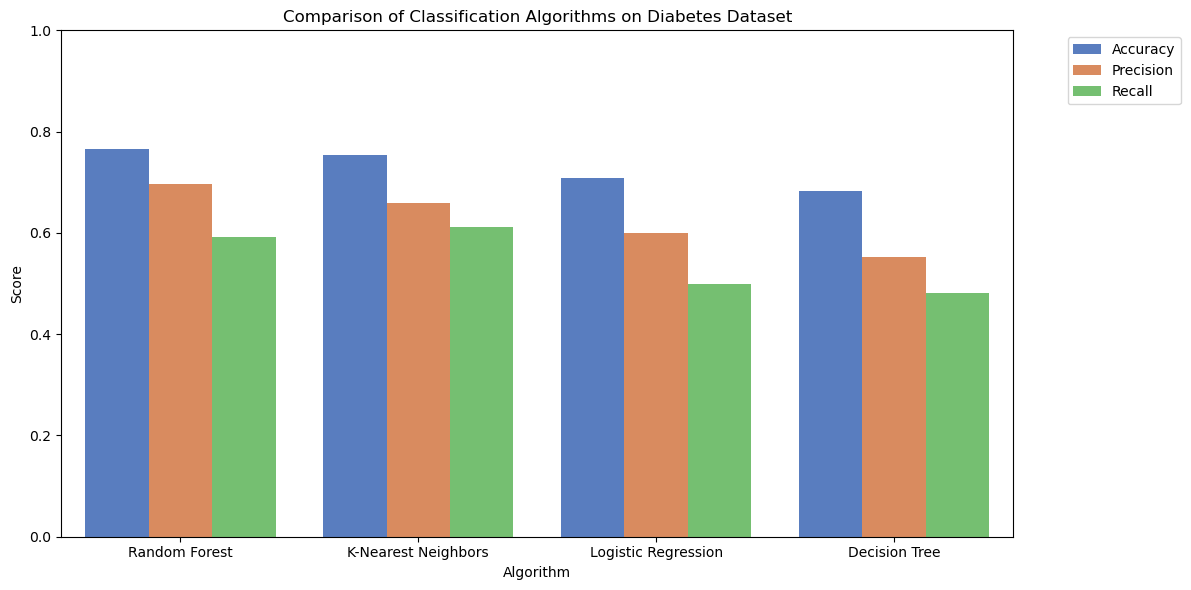

In [8]:
melted_df = results_df.melt(id_vars="Algorithm", value_vars=["Accuracy", "Precision", "Recall"], 
                            var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(x="Algorithm", y="Score", hue="Metric", data=melted_df, palette="muted")
plt.title("Comparison of Classification Algorithms on Diabetes Dataset")
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Random Forest Classifier is the best model overall and also correctly identifying people who actually have diabetes